In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_excel('nba_bersih_2.xlsx')
df

,Age,Weight,Salary,Tinggi
0,25,180,7730337,49
1,25,235,6796117,49
2,27,205,2839073,51
3,22,185,1148640,46
4,29,231,5000000,53
...,...,...,...,...
453,26,203,2433333,50
454,24,179,900000,48
455,26,256,2900000,50
456,26,231,947276,50


In [111]:
features = df[['Tinggi', 'Weight', 'Age','Salary']]

<Axes: xlabel='Tinggi', ylabel='Weight'>

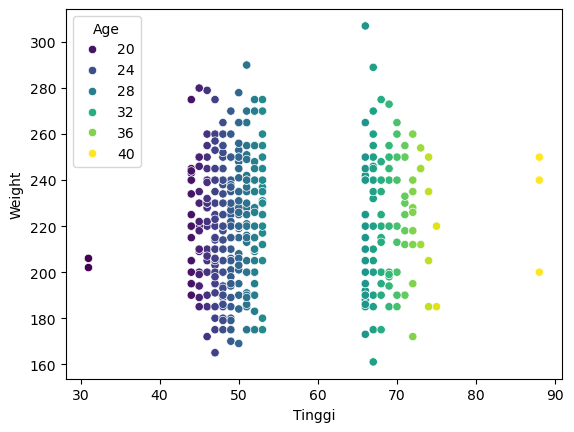

In [112]:
import seaborn as sns
sns.scatterplot(data=df, x='Tinggi', y='Weight', hue='Age', palette='viridis')

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10,max_iter=300)
y_kmeans = kmeans.fit(features)

d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [114]:
kmeans.cluster_centers_

array([[5.24693878e+01, 2.19598639e+02, 2.61020408e+01, 1.73837399e+06],
       [5.61538462e+01, 2.30384615e+02, 2.80923077e+01, 1.56337473e+07],
       [5.78686869e+01, 2.21404040e+02, 2.86565657e+01, 6.73364099e+06]])

In [115]:

kmeans.n_iter_

12

In [116]:
kmeans.labels_

array([2, 2, 0, 0, 2, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 2, 0, 0, 1, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 2, 0,
       2, 1, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 1, 0, 1, 1, 2, 0, 0, 0,
       0, 1, 0, 0, 0, 2, 0, 2, 1, 0, 1, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 2, 0, 2, 0, 2, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       2, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 1, 0, 0, 1, 2, 0, 0, 2, 0, 0, 1,
       2, 0, 2, 2, 0, 0, 2, 0, 1, 0, 1, 0, 0, 2, 1, 1, 0, 0, 0, 0, 1, 0,
       2, 2, 2, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 2, 2, 0, 0, 0,
       2, 1, 2, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1,
       1, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 2, 1, 0, 0, 2,
       2, 0, 2, 2, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 2, 0,
       0, 1, 0, 0, 0, 0, 0, 2, 2, 0, 2, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 2, 2, 0, 2,

<Axes: xlabel='Tinggi', ylabel='Weight'>

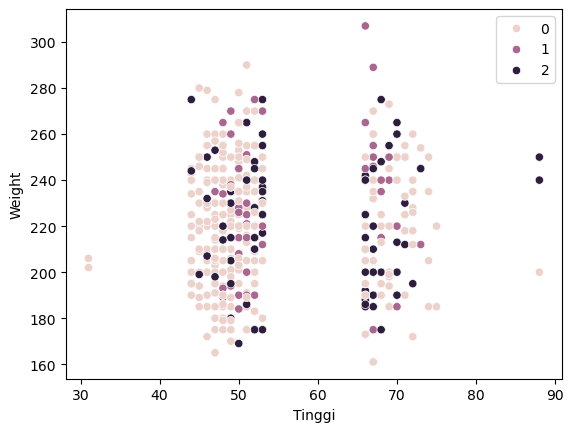

In [118]:
sns.scatterplot(data=df, x='Tinggi', y='Weight', hue=kmeans.labels_)

In [119]:
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,
}
sse = []
for k in range(1, 7):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(features)
    sse.append(kmeans.inertia_)

d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

In [120]:
import matplotlib.pyplot as plt

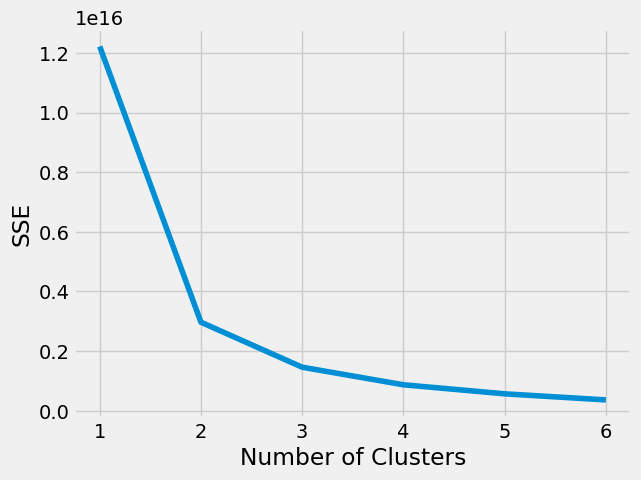

In [121]:
plt.style.use("fivethirtyeight")
plt.plot(range(1, 7), sse)
plt.xticks(range(1, 7))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [122]:
!pip install kneed


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: D:\python.exe -m pip install --upgrade pip


In [123]:
from kneed import KneeLocator
kl = KneeLocator(range(1, 7), sse, curve="convex", direction="decreasing")

In [124]:
kl.elbow

np.int64(2)

In [125]:
from sklearn.metrics import silhouette_score

In [126]:
## Silhouette coeficient
silhouette_coefficients = []
# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(features)
    score = silhouette_score(features, kmeans.labels_)
    silhouette_coefficients.append(score)

d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

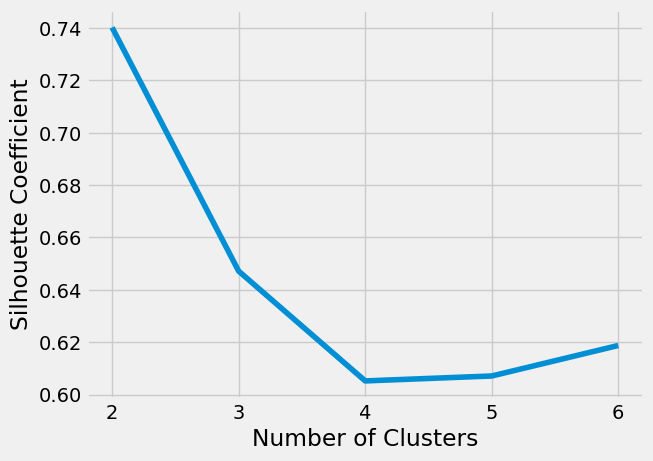

In [127]:
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
plt.plot(range(2, 7), silhouette_coefficients)
plt.xticks(range(2, 7))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

In [130]:
from sklearn.cluster import KMeans
X = features.iloc[:, [0, 1, 2, 3]].values
kmeans = KMeans(n_clusters = 3, random_state = 0, n_init='auto',max_iter=300)
y_kmeans = kmeans.fit_predict(X)

d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


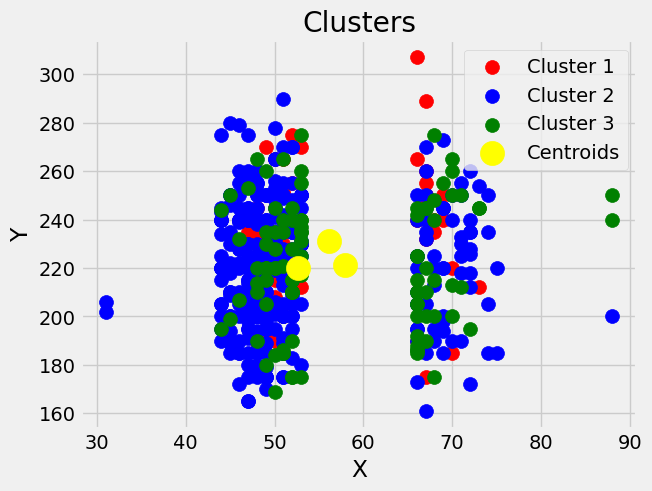

In [131]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
#plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
#plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.savefig("Cluster contoh.png")
plt.show()

In [132]:
X[y_kmeans == 5, 1]

array([], dtype=int64)

In [135]:
y_kmeans

array([2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 2, 2, 1, 1, 0, 2, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 1,
       2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 0, 2, 2, 1, 1, 1,
       1, 0, 1, 1, 1, 2, 1, 2, 0, 1, 0, 1, 0, 1, 1, 2, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       2, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 0, 1, 1, 0, 2, 1, 1, 2, 1, 1, 0,
       1, 1, 2, 2, 1, 1, 2, 1, 0, 1, 0, 1, 1, 2, 0, 0, 1, 1, 1, 1, 0, 1,
       2, 2, 2, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 2, 2, 1, 1, 1,
       2, 0, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0,
       0, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 2, 2, 0, 1, 1, 2,
       2, 1, 2, 2, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1,
       1, 0, 1, 1, 1, 1, 1, 2, 2, 1, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2,
       1, 1, 0, 1, 2, 1, 1, 1, 0, 1, 1, 2, 2, 1, 2,

In [134]:
!pip install scikit-learn-extra

  Using cached scikit-learn-extra-0.3.0.tar.gz (818 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached scikit_learn-1.9.1-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
Using cached threadpoolctl-3.7.0-py3-none

  error: subprocess-exited-with-error
  
  × Building wheel for scikit-learn-extra (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [77 lines of output]
      C:\Users\ASUS Vivobook\AppData\Local\Temp\pip-build-env-7c6l5xnt\overlay\Lib\site-packages\setuptools\dist.py:599: SetuptoolsDeprecationWarning: Invalid dash-separated key 'description-file' in 'metadata' (setup.cfg), please use the underscore name 'description_file' instead.
      !!
      
              ********************************************************************************
              Usage of dash-separated 'description-file' will not be supported in future
              versions. Please use the underscore name 'description_file' instead.
              (Affected: scikit-learn-extra).
      
              Available configuration options are listed in:
              https://setuptools.pypa.io/en/latest/userguide/declarative_config.html
      
              This deprecation is overdue, please update y